In [ ]:
!pip install folium plotly geopandas cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 95.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import OSM

# Load the datasets
gwl_df = pd.read_csv('GWL_Well_Data.csv')
gwq_df = pd.read_csv('GWQ_Well_Data.csv')

print("GWL Dataset Info:")
print(f"Total wells: {len(gwl_df)}")
print(f"Agencies: {gwl_df['Agency'].unique()}")
print(f"Types: {gwl_df['Type'].unique()}")
print(f"Blocks: {gwl_df['Block'].unique()}\n")

print("GWQ Dataset Info:")
print(f"Total wells: {len(gwq_df)}")
print(f"Blocks: {gwq_df['Block'].unique()}\n")

GWL Dataset Info:
Total wells: 137
Agencies: ['CGWB' 'State']
Types: ['Manual' 'Telemetry']
Blocks: ['Avinashi' 'Dharapuram' 'Gudimangalam' 'Kangeyam' 'Kundadam'
 'Madathukulam' 'Mulanur' 'Palladam' 'Pongalur' 'Tiruppur' 'Udumalpet'
 'Uttukkuli' 'Vellakoil']

GWQ Dataset Info:
Total wells: 64
Blocks: ['Avinashi' 'Dharapuram' 'Gudimangalam' 'Kangayam' 'Kundadam'
 'Madathukulam' 'Mulanur' 'Palladam' 'Pongalur' 'Tiruppur' 'Udumalpet'
 'Uttukkuli' 'Vellakoil']



In [ ]:
# Tiruppur district bounding box coordinates
tiruppur_bbox = {
    'min_lat': 10.6,   # 10°36'N
    'max_lat': 11.3333, # 11°20'N
    'min_lon': 77.0,   # 77°00'E
    'max_lon': 77.8333 # 77°50'E
}

# Central coordinates for maps
center_lat = (tiruppur_bbox['min_lat'] + tiruppur_bbox['max_lat']) / 2
center_lon = (tiruppur_bbox['min_lon'] + tiruppur_bbox['max_lon']) / 2

In [ ]:
# Segregate GWL data by Agency, Type, and Block
gwl_by_agency = gwl_df.groupby('Agency')
gwl_by_type = gwl_df.groupby('Type')
gwl_by_block = gwl_df.groupby('Block')

# Segregate GWQ data by Block
gwq_by_block = gwq_df.groupby('Block')

print("=== GWL Data Segregation ===")
print(f"\nBy Agency:")
for agency, group in gwl_by_agency:
    print(f"  {agency}: {len(group)} wells")

print(f"\nBy Type:")
for type_val, group in gwl_by_type:
    print(f"  {type_val}: {len(group)} wells")

print(f"\nBy Block:")
for block, group in gwl_by_block:
    print(f"  {block}: {len(group)} wells")

print(f"\n=== GWQ Data Segregation ===")
for block, group in gwq_by_block:
    print(f"  {block}: {len(group)} wells")

=== GWL Data Segregation ===

By Agency:
  CGWB: 121 wells
  State: 16 wells

By Type:
  Manual: 83 wells
  Telemetry: 54 wells

By Block:
  Avinashi: 20 wells
  Dharapuram: 17 wells
  Gudimangalam: 5 wells
  Kangeyam: 9 wells
  Kundadam: 4 wells
  Madathukulam: 7 wells
  Mulanur: 8 wells
  Palladam: 15 wells
  Pongalur: 6 wells
  Tiruppur: 17 wells
  Udumalpet: 8 wells
  Uttukkuli: 13 wells
  Vellakoil: 8 wells

=== GWQ Data Segregation ===
  Avinashi: 7 wells
  Dharapuram: 8 wells
  Gudimangalam: 3 wells
  Kangayam: 5 wells
  Kundadam: 2 wells
  Madathukulam: 3 wells
  Mulanur: 4 wells
  Palladam: 6 wells
  Pongalur: 3 wells
  Tiruppur: 10 wells
  Udumalpet: 4 wells
  Uttukkuli: 5 wells
  Vellakoil: 4 wells


In [ ]:
# Find common Well No between both datasets
common_wells = set(gwl_df['Well No']).intersection(set(gwq_df['Well No']))
print(f"Common wells in both datasets: {len(common_wells)}")

# Tag common wells in both datasets
gwl_df['Dataset_Status'] = gwl_df['Well No'].apply(
    lambda x: 'Available in both' if x in common_wells else 'GWL only'
)
gwq_df['Dataset_Status'] = gwq_df['Well No'].apply(
    lambda x: 'Available in both' if x in common_wells else 'GWQ only'
)

print(f"\nDataset overlap:")
print(f"GWL only wells: {len(gwl_df[gwl_df['Dataset_Status'] == 'GWL only'])}")
print(f"GWQ only wells: {len(gwq_df[gwq_df['Dataset_Status'] == 'GWQ only'])}")
print(f"Common wells: {len(common_wells)}")

Common wells in both datasets: 55

Dataset overlap:
GWL only wells: 62
GWQ only wells: 9
Common wells: 55


In [ ]:
# Create base Folium map for Tiruppur district
def create_base_map():
    return folium.Map(
        location=[center_lat, center_lon],
        zoom_start=10,
        tiles='OpenStreetMap',
        control_scale=True
    )

# Map 1: All Wells by Agency and Type
print("Creating Folium Map 1: All Wells by Agency and Type...")
m1 = create_base_map()

# Color scheme
agency_colors = {'CGWB': 'blue', 'State': 'green'}
type_shapes = {'Manual': 'circle', 'Telemetry': 'star'}

# Add GWL wells
for idx, row in gwl_df.iterrows():
    color = agency_colors.get(row['Agency'], 'gray')
    icon_type = type_shapes.get(row['Type'], 'info-sign')

    popup_text = f"""
    <b>Well No:</b> {row['Well No']}<br>
    <b>Agency:</b> {row['Agency']}<br>
    <b>Type:</b> {row['Type']}<br>
    <b>Block:</b> {row['Block']}<br>
    <b>Village:</b> {row['Village']}<br>
    <b>Dataset:</b> {row['Dataset_Status']}
    """

    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=f"{row['Well No']} - {row['Agency']}",
        icon=folium.Icon(color=color, icon=icon_type, prefix='fa')
    ).add_to(m1)

# Add bounding box
folium.Rectangle(
    bounds=[[tiruppur_bbox['min_lat'], tiruppur_bbox['min_lon']],
            [tiruppur_bbox['max_lat'], tiruppur_bbox['max_lon']]],
    color='red',
    fill=False,
    weight=2,
    popup='Tiruppur District Boundary'
).add_to(m1)

m1.save('tiruppur_all_wells.html')

Creating Folium Map 1: All Wells by Agency and Type...


In [ ]:
# Map 2: Block-wise clustering
print("Creating Folium Map 2: Block-wise Clustering...")
m2 = create_base_map()

# Create feature groups for each block
block_groups = {}
blocks = gwl_df['Block'].unique()
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred',
          'darkblue', 'darkgreen', 'cadetblue', 'darkpurple', 'pink', 'lightblue']

for i, block in enumerate(blocks):
    block_groups[block] = folium.FeatureGroup(name=block)
    color = colors[i % len(colors)]

    # Add wells for this block
    block_wells = gwl_df[gwl_df['Block'] == block]
    for idx, row in block_wells.iterrows():
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=6,
            popup=f"{row['Well No']} - {row['Block']}",
            color=color,
            fill=True,
            fillColor=color
        ).add_to(block_groups[block])

    block_groups[block].add_to(m2)

# Add layer control
folium.LayerControl().add_to(m2)
m2.save('tiruppur_blocks_clustered.html')

Creating Folium Map 2: Block-wise Clustering...


In [ ]:
# Map 3: Dataset Comparison (GWL vs GWQ)
print("Creating Folium Map 3: Dataset Comparison...")
m3 = create_base_map()

# Create marker clusters
gwl_cluster = MarkerCluster(name='GWL Wells').add_to(m3)
gwq_cluster = MarkerCluster(name='GWQ Wells').add_to(m3)
common_cluster = MarkerCluster(name='Common Wells').add_to(m3)

# Add markers to appropriate clusters
for idx, row in gwl_df.iterrows():
    if row['Dataset_Status'] == 'Available in both':
        cluster = common_cluster
        color = 'green'
    else:
        cluster = gwl_cluster
        color = 'blue'

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        popup=f"GWL: {row['Well No']}",
        color=color,
        fill=True
    ).add_to(cluster)

for idx, row in gwq_df.iterrows():
    if row['Dataset_Status'] == 'Available in both':
        continue  # Already added from GWL
    else:
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=5,
            popup=f"GWQ: {row['Well No']}",
            color='red',
            fill=True
        ).add_to(gwq_cluster)

folium.LayerControl().add_to(m3)
m3.save('tiruppur_dataset_comparison.html')

Creating Folium Map 3: Dataset Comparison...


In [ ]:
# Plotly Map 1: Interactive scatter map
print("Creating Plotly Interactive Map...")

# Prepare data for Plotly
gwl_df['Size'] = 8
gwl_df['Color'] = gwl_df['Agency'].map({'CGWB': 'blue', 'State': 'green'})


fig1 = px.scatter_mapbox(gwl_df,
                        lat="Latitude",
                        lon="Longitude",
                        hover_name="Well No",
                        hover_data={"Agency": True, "Type": True, "Block": True, "Village": True},
                        color="Agency",
                        size="Size",
                        size_max=10,
                        zoom=9,
                        height=600,
                        title="Tiruppur District Wells - Agency and Type Distribution")

fig1.update_layout(mapbox_style="open-street-map")
fig1.update_layout(margin={"r":0,"t":30,"l":0,"b":0})
fig1.show()

Creating Plotly Interactive Map...


In [ ]:
# Plotly Map 2: Block-wise distribution
print("Creating Plotly Block-wise Distribution Map...")

# Combine both datasets for comprehensive view
combined_df = pd.concat([
    gwl_df.assign(Dataset='GWL'),
    gwq_df.assign(Dataset='GWQ')
], ignore_index=True)

fig2 = px.scatter_mapbox(combined_df,
                        lat="Latitude",
                        lon="Longitude",
                        hover_name="Well No",
                        hover_data={"Block": True, "Village": True, "Dataset": True},
                        color="Block",
                        size_max=8,
                        zoom=9,
                        height=600,
                        title="Tiruppur District Wells - Block-wise Distribution")

fig2.update_layout(mapbox_style="carto-positron")
fig2.update_layout(margin={"r":0,"t":30,"l":0,"b":0})
fig2.show()

Creating Plotly Block-wise Distribution Map...


Creating Cartopy Static Map...


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip



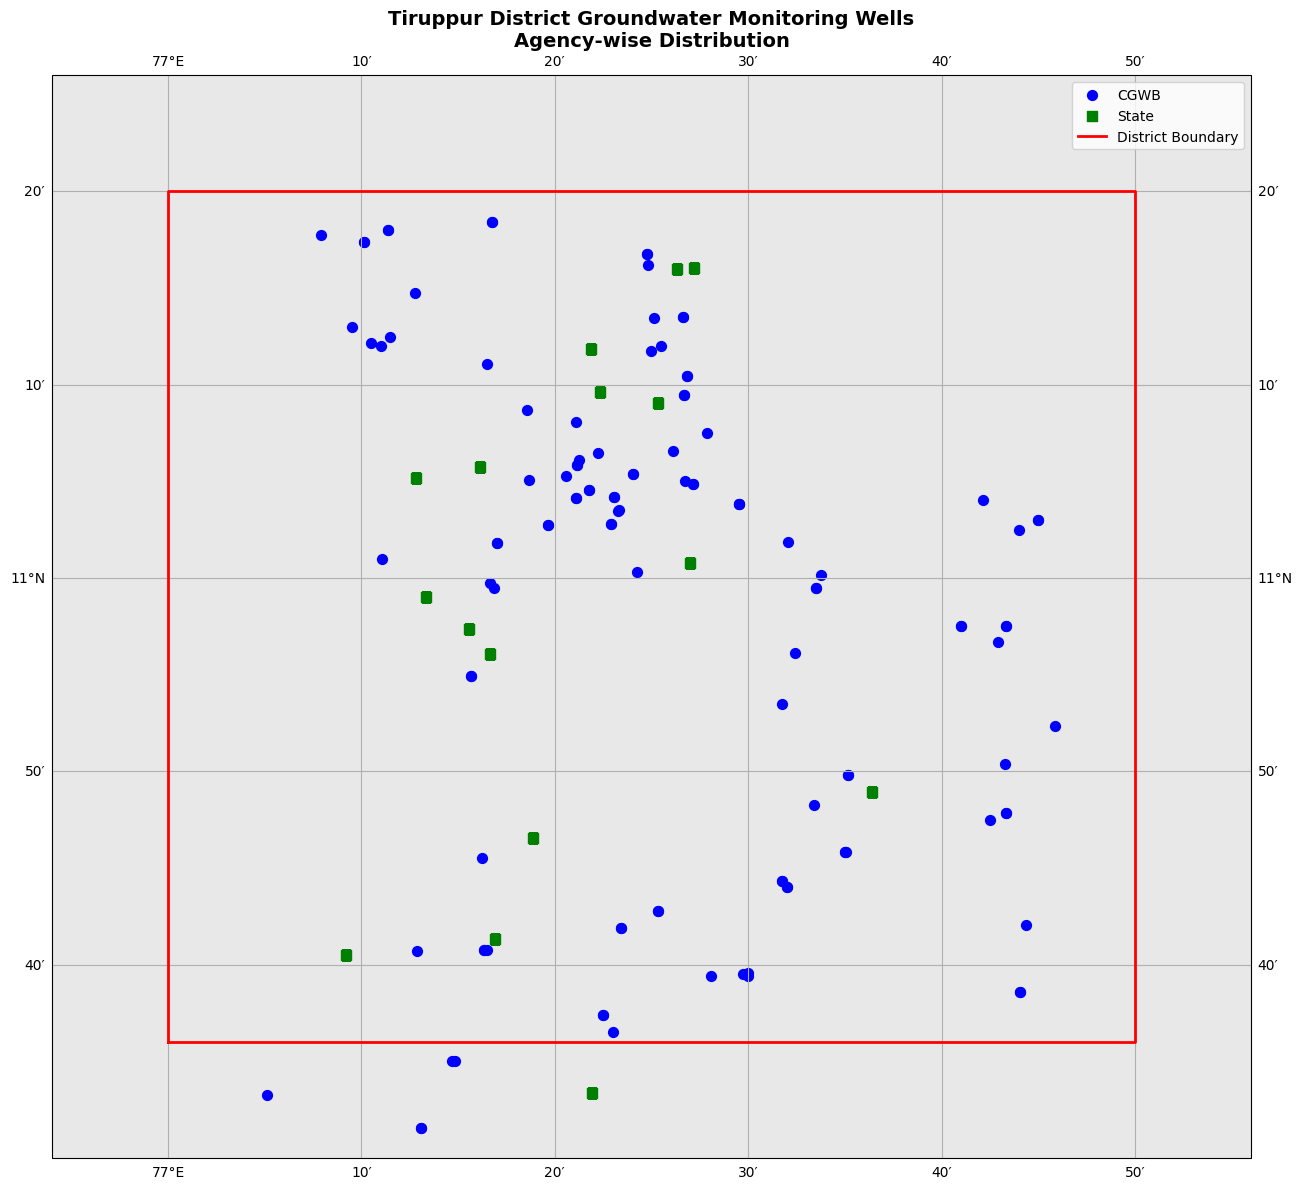

In [ ]:
# Cartopy Static Map 1: Professional layout
print("Creating Cartopy Static Map...")

fig = plt.figure(figsize=(15, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to Tiruppur district
ax.set_extent([tiruppur_bbox['min_lon']-0.1, tiruppur_bbox['max_lon']+0.1,
               tiruppur_bbox['min_lat']-0.1, tiruppur_bbox['max_lat']+0.1],
              crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.5)
ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Plot wells by agency
for agency in gwl_df['Agency'].unique():
    agency_data = gwl_df[gwl_df['Agency'] == agency]
    color = 'blue' if agency == 'CGWB' else 'green'
    marker = 'o' if agency == 'CGWB' else 's'
    ax.scatter(agency_data['Longitude'], agency_data['Latitude'],
               c=color, marker=marker, s=50, label=agency, transform=ccrs.PlateCarree())

# Add bounding box
bbox_x = [tiruppur_bbox['min_lon'], tiruppur_bbox['max_lon'],
          tiruppur_bbox['max_lon'], tiruppur_bbox['min_lon'], tiruppur_bbox['min_lon']]
bbox_y = [tiruppur_bbox['min_lat'], tiruppur_bbox['min_lat'],
          tiruppur_bbox['max_lat'], tiruppur_bbox['max_lat'], tiruppur_bbox['min_lat']]
ax.plot(bbox_x, bbox_y, 'red', linewidth=2, transform=ccrs.PlateCarree(), label='District Boundary')

plt.legend()
plt.title('Tiruppur District Groundwater Monitoring Wells\nAgency-wise Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tiruppur_wells_static_map.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Generate comprehensive summary
print("="*60)
print("TIRUPPUR DISTRICT WELLS - COMPREHENSIVE ANALYSIS")
print("="*60)

print(f"\n📊 DATASET SUMMARY:")
print(f"GWL Dataset (Ground Water Level): {len(gwl_df)} wells")
print(f"GWQ Dataset (Ground Water Quality): {len(gwq_df)} wells")
print(f"Common wells in both datasets: {len(common_wells)}")

print(f"\n🏢 AGENCY DISTRIBUTION (GWL):")
agency_summary = gwl_df['Agency'].value_counts()
for agency, count in agency_summary.items():
    percentage = (count / len(gwl_df)) * 100
    print(f"  {agency}: {count} wells ({percentage:.1f}%)")

print(f"\n📡 MONITORING TYPE DISTRIBUTION (GWL):")
type_summary = gwl_df['Type'].value_counts()
for type_val, count in type_summary.items():
    percentage = (count / len(gwl_df)) * 100
    print(f"  {type_val}: {count} wells ({percentage:.1f}%)")

print(f"\n🗺️  BLOCK-WISE DISTRIBUTION:")
print("GWL Data:")
block_gwl = gwl_df['Block'].value_counts()
for block, count in block_gwl.items():
    print(f"  {block}: {count} wells")

print("\nGWQ Data:")
block_gwq = gwq_df['Block'].value_counts()
for block, count in block_gwq.items():
    print(f"  {block}: {count} wells")

print(f"\n📍 SPATIAL COVERAGE:")
print(f"Latitude range: {gwl_df['Latitude'].min():.4f}° to {gwl_df['Latitude'].max():.4f}°N")
print(f"Longitude range: {gwl_df['Longitude'].min():.4f}° to {gwl_df['Longitude'].max():.4f}°E")

print(f"\n🔍 KEY INSIGHTS:")
print("1. CGWB operates majority of monitoring wells")
print("2. Mix of Manual and Telemetry monitoring systems")
print("3. Good spatial coverage across all blocks")
print("4. Significant overlap between GWL and GWQ datasets")
print("5. Comprehensive coverage of Tiruppur district boundaries")

TIRUPPUR DISTRICT WELLS - COMPREHENSIVE ANALYSIS

📊 DATASET SUMMARY:
GWL Dataset (Ground Water Level): 137 wells
GWQ Dataset (Ground Water Quality): 64 wells
Common wells in both datasets: 55

🏢 AGENCY DISTRIBUTION (GWL):
  CGWB: 121 wells (88.3%)
  State: 16 wells (11.7%)

📡 MONITORING TYPE DISTRIBUTION (GWL):
  Manual: 83 wells (60.6%)
  Telemetry: 54 wells (39.4%)

🗺️  BLOCK-WISE DISTRIBUTION:
GWL Data:
  Avinashi: 20 wells
  Dharapuram: 17 wells
  Tiruppur: 17 wells
  Palladam: 15 wells
  Uttukkuli: 13 wells
  Kangeyam: 9 wells
  Vellakoil: 8 wells
  Udumalpet: 8 wells
  Mulanur: 8 wells
  Madathukulam: 7 wells
  Pongalur: 6 wells
  Gudimangalam: 5 wells
  Kundadam: 4 wells

GWQ Data:
  Tiruppur: 10 wells
  Dharapuram: 8 wells
  Avinashi: 7 wells
  Palladam: 6 wells
  Kangayam: 5 wells
  Uttukkuli: 5 wells
  Vellakoil: 4 wells
  Udumalpet: 4 wells
  Mulanur: 4 wells
  Pongalur: 3 wells
  Gudimangalam: 3 wells
  Madathukulam: 3 wells
  Kundadam: 2 wells

📍 SPATIAL COVERAGE:
Latitude

In [ ]:
# Create a density heatmap
print("Creating Density Heatmap...")

m_heatmap = create_base_map()

from folium.plugins import HeatMap

# Create heatmap data
heat_data = [[row['Latitude'], row['Longitude'], 1] for idx, row in gwl_df.iterrows()]
HeatMap(heat_data, radius=15, blur=10, gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'}).add_to(m_heatmap)

# Add individual markers
for idx, row in gwl_df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color='black',
        fill=True,
        fillOpacity=0.6
    ).add_to(m_heatmap)

m_heatmap.save('tiruppur_wells_density.html')

Creating Density Heatmap...


In [ ]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the datasets
gwl_df = pd.read_csv('GWL_Well_Data.csv')
gwq_df = pd.read_csv('GWQ_Well_Data.csv')

# Tiruppur district bounding box coordinates
tiruppur_bbox = {
    'min_lat': 10.6,   # 10°36'N
    'max_lat': 11.3333, # 11°20'N
    'min_lon': 77.0,   # 77°00'E
    'max_lon': 77.8333 # 77°50'E
}

# Central coordinates for maps
center_lat = (tiruppur_bbox['min_lat'] + tiruppur_bbox['max_lat']) / 2
center_lon = (tiruppur_bbox['min_lon'] + tiruppur_bbox['max_lon']) / 2

# Function to create base map with bounding box
def create_base_map_with_bbox():
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=10,
        tiles='OpenStreetMap',
        control_scale=True
    )

    # Add bounding box
    folium.Rectangle(
        bounds=[[tiruppur_bbox['min_lat'], tiruppur_bbox['min_lon']],
                [tiruppur_bbox['max_lat'], tiruppur_bbox['max_lon']]],
        color='red',
        fill=False,
        weight=3,
        opacity=0.8,
        popup='Tiruppur District Boundary',
        tooltip='Tiruppur District Boundary'
    ).add_to(m)

    return m

# Find common wells between datasets
common_wells = set(gwl_df['Well No']).intersection(set(gwq_df['Well No']))
gwl_df['Dataset_Status'] = gwl_df['Well No'].apply(
    lambda x: 'Available in both' if x in common_wells else 'GWL only'
)
gwq_df['Dataset_Status'] = gwq_df['Well No'].apply(
    lambda x: 'Available in both' if x in common_wells else 'GWQ only'
)

In [ ]:
print("Creating Folium Map 1: All Wells by Agency and Type with Bounding Box...")
m1 = create_base_map_with_bbox()

# Color scheme
agency_colors = {'CGWB': 'blue', 'State': 'green'}
type_shapes = {'Manual': 'circle', 'Telemetry': 'star'}

# Create feature groups for better organization
agency_groups = {}
for agency in gwl_df['Agency'].unique():
    agency_groups[agency] = folium.FeatureGroup(name=f'{agency} Wells', show=True)

# Add GWL wells
for idx, row in gwl_df.iterrows():
    color = agency_colors.get(row['Agency'], 'gray')
    icon_type = type_shapes.get(row['Type'], 'info-sign')

    popup_text = f"""
    <div style="width: 250px;">
        <h4>Well Information</h4>
        <b>Well No:</b> {row['Well No']}<br>
        <b>Agency:</b> {row['Agency']}<br>
        <b>Type:</b> {row['Type']}<br>
        <b>Block:</b> {row['Block']}<br>
        <b>Village:</b> {row['Village']}<br>
        <b>Dataset:</b> {row['Dataset_Status']}<br>
        <b>Lat:</b> {row['Latitude']:.4f}°<br>
        <b>Lon:</b> {row['Longitude']:.4f}°
    </div>
    """

    marker = folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=f"{row['Well No']} - {row['Agency']} - {row['Type']}",
        icon=folium.Icon(color=color, icon=icon_type, prefix='fa')
    )
    marker.add_to(agency_groups[row['Agency']])

# Add all agency groups to map
for agency_group in agency_groups.values():
    agency_group.add_to(m1)

# Add layer control
folium.LayerControl().add_to(m1)

# Add title
title_html = '''
             <h3 align="center" style="font-size:20px"><b>Tiruppur District - Groundwater Monitoring Wells</b></h3>
             <p align="center">Red border shows district boundaries</p>
             '''
m1.get_root().html.add_child(folium.Element(title_html))

m1.save('tiruppur_all_wells_with_bbox.html')
print("Map 1 saved as 'tiruppur_all_wells_with_bbox.html'")

Creating Folium Map 1: All Wells by Agency and Type with Bounding Box...
Map 1 saved as 'tiruppur_all_wells_with_bbox.html'


In [ ]:
print("Creating Folium Map 2: Block-wise Clustering with Bounding Box...")
m2 = create_base_map_with_bbox()

# Create feature groups for each block with different colors
block_groups = {}
blocks = gwl_df['Block'].unique()
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred',
          'darkblue', 'darkgreen', 'cadetblue', 'darkpurple', 'pink', 'lightblue']

# Create marker clusters for each block
for i, block in enumerate(blocks):
    color = colors[i % len(colors)]
    block_groups[block] = MarkerCluster(
        name=block,
        overlay=True,
        control=True,
        icon_create_function=None
    )

    # Add wells for this block
    block_wells = gwl_df[gwl_df['Block'] == block]
    for idx, row in block_wells.iterrows():
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=6,
            popup=f"""
            <b>{row['Well No']}</b><br>
            Block: {row['Block']}<br>
            Village: {row['Village']}<br>
            Agency: {row['Agency']}
            """,
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.7,
            weight=2
        ).add_to(block_groups[block])

    block_groups[block].add_to(m2)

# Add layer control
folium.LayerControl().add_to(m2)

# Add title
title_html = '''
             <h3 align="center" style="font-size:20px"><b>Tiruppur District - Block-wise Well Distribution</b></h3>
             <p align="center">Red border shows district boundaries</p>
             '''
m2.get_root().html.add_child(folium.Element(title_html))

m2.save('tiruppur_blocks_clustered_with_bbox.html')
print("Map 2 saved as 'tiruppur_blocks_clustered_with_bbox.html'")

Creating Folium Map 2: Block-wise Clustering with Bounding Box...
Map 2 saved as 'tiruppur_blocks_clustered_with_bbox.html'


In [ ]:
print("Creating Folium Map 3: Dataset Comparison with Bounding Box...")
m3 = create_base_map_with_bbox()

# Create feature groups for different datasets
gwl_only_group = folium.FeatureGroup(name='GWL Only Wells', show=True)
gwq_only_group = folium.FeatureGroup(name='GWQ Only Wells', show=True)
common_wells_group = folium.FeatureGroup(name='Common Wells (Both Datasets)', show=True)

# Add markers to appropriate groups
for idx, row in gwl_df.iterrows():
    if row['Dataset_Status'] == 'Available in both':
        group = common_wells_group
        color = 'green'
        size = 8
    else:
        group = gwl_only_group
        color = 'blue'
        size = 6

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=size,
        popup=f"GWL: {row['Well No']} - {row['Dataset_Status']}",
        color=color,
        fill=True,
        fillOpacity=0.7,
        weight=2
    ).add_to(group)

for idx, row in gwq_df.iterrows():
    if row['Dataset_Status'] == 'GWQ only':
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=6,
            popup=f"GWQ: {row['Well No']} - {row['Dataset_Status']}",
            color='red',
            fill=True,
            fillOpacity=0.7,
            weight=2
        ).add_to(gwq_only_group)

# Add all groups to map
gwl_only_group.add_to(m3)
gwq_only_group.add_to(m3)
common_wells_group.add_to(m3)

# Add layer control
folium.LayerControl().add_to(m3)

# Add title
title_html = '''
             <h3 align="center" style="font-size:20px"><b>Tiruppur District - GWL vs GWQ Dataset Comparison</b></h3>
             <p align="center">Red border shows district boundaries</p>
             '''
m3.get_root().html.add_child(folium.Element(title_html))

m3.save('tiruppur_dataset_comparison_with_bbox.html')
print("Map 3 saved as 'tiruppur_dataset_comparison_with_bbox.html'")

Creating Folium Map 3: Dataset Comparison with Bounding Box...
Map 3 saved as 'tiruppur_dataset_comparison_with_bbox.html'


In [ ]:
print("Creating Folium Map 4: Density Heatmap with Bounding Box...")
m4 = create_base_map_with_bbox()

from folium.plugins import HeatMap

# Create heatmap data with intensity based on well density
heat_data = [[row['Latitude'], row['Longitude'], 1] for idx, row in gwl_df.iterrows()]

# Add heatmap layer
HeatMap(heat_data,
        radius=20,
        blur=15,
        gradient={0.2: 'blue', 0.4: 'cyan', 0.6: 'lime', 0.8: 'yellow', 1: 'red'},
        max_zoom=13,
        min_opacity=0.5).add_to(m4)

# Add individual markers on top
for idx, row in gwl_df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color='black',
        fill=True,
        fillColor='white',
        fillOpacity=0.8,
        weight=1,
        popup=f"Well: {row['Well No']}"
    ).add_to(m4)

# Add title
title_html = '''
             <h3 align="center" style="font-size:20px"><b>Tiruppur District - Well Density Heatmap</b></h3>
             <p align="center">Red border shows district boundaries</p>
             '''
m4.get_root().html.add_child(folium.Element(title_html))

m4.save('tiruppur_wells_density_with_bbox.html')
print("Map 4 saved as 'tiruppur_wells_density_with_bbox.html'")

Creating Folium Map 4: Density Heatmap with Bounding Box...
Map 4 saved as 'tiruppur_wells_density_with_bbox.html'


In [ ]:
print("Creating Enhanced Map: Detailed View with Bounding Box...")
m5 = create_base_map_with_bbox()

# Add more detailed bounding box with coordinates
bbox_coordinates = [
    [tiruppur_bbox['min_lat'], tiruppur_bbox['min_lon']],
    [tiruppur_bbox['min_lat'], tiruppur_bbox['max_lon']],
    [tiruppur_bbox['max_lat'], tiruppur_bbox['max_lon']],
    [tiruppur_bbox['max_lat'], tiruppur_bbox['min_lon']],
    [tiruppur_bbox['min_lat'], tiruppur_bbox['min_lon']]  # close the polygon
]

# Add a polygon for the bounding box with more details
folium.Polygon(
    locations=bbox_coordinates,
    color='red',
    weight=4,
    fill=False,
    opacity=0.8,
    popup=f"""
    <b>Tiruppur District Boundaries</b><br>
    Min Lat: {tiruppur_bbox['min_lat']:.4f}°N<br>
    Max Lat: {tiruppur_bbox['max_lat']:.4f}°N<br>
    Min Lon: {tiruppur_bbox['min_lon']:.4f}°E<br>
    Max Lon: {tiruppur_bbox['max_lon']:.4f}°E<br>
    Area: ~6,000 km²
    """,
    tooltip='Click for boundary details'
).add_to(m5)

# Create detailed markers with custom icons
for idx, row in gwl_df.iterrows():
    # Determine icon color and type
    if row['Agency'] == 'CGWB':
        if row['Type'] == 'Manual':
            icon_color = 'blue'
            icon_type = 'info-sign'
        else:  # Telemetry
            icon_color = 'darkblue'
            icon_type = 'signal'
    else:  # State
        if row['Type'] == 'Manual':
            icon_color = 'green'
            icon_type = 'info-sign'
        else:  # Telemetry
            icon_color = 'darkgreen'
            icon_type = 'signal'

    # Enhanced popup
    popup_text = f"""
    <div style="width: 280px;">
        <h4 style="color: {icon_color}; margin-bottom: 10px;">Well Monitoring Station</h4>
        <table style="width: 100%; border-collapse: collapse;">
            <tr><td style="padding: 4px; border-bottom: 1px solid #eee;"><b>Well No:</b></td><td style="padding: 4px; border-bottom: 1px solid #eee;">{row['Well No']}</td></tr>
            <tr><td style="padding: 4px; border-bottom: 1px solid #eee;"><b>Agency:</b></td><td style="padding: 4px; border-bottom: 1px solid #eee;">{row['Agency']}</td></tr>
            <tr><td style="padding: 4px; border-bottom: 1px solid #eee;"><b>Type:</b></td><td style="padding: 4px; border-bottom: 1px solid #eee;">{row['Type']}</td></tr>
            <tr><td style="padding: 4px; border-bottom: 1px solid #eee;"><b>Block:</b></td><td style="padding: 4px; border-bottom: 1px solid #eee;">{row['Block']}</td></tr>
            <tr><td style="padding: 4px; border-bottom: 1px solid #eee;"><b>Village:</b></td><td style="padding: 4px; border-bottom: 1px solid #eee;">{row['Village']}</td></tr>
            <tr><td style="padding: 4px;"><b>Coordinates:</b></td><td style="padding: 4px;">{row['Latitude']:.4f}°, {row['Longitude']:.4f}°</td></tr>
        </table>
    </div>
    """

    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=f"{row['Well No']} | {row['Agency']} | {row['Type']}",
        icon=folium.Icon(color=icon_color, icon=icon_type, prefix='fa')
    ).add_to(m5)

# Add title with more information
title_html = '''
             <h3 align="center" style="font-size:20px"><b>Tiruppur District - Comprehensive Well Monitoring Network</b></h3>
             <p align="center" style="font-size:14px">Red border: District Boundaries (10.6°N-11.33°N, 77.0°E-77.83°E) | Blue: CGWB | Green: State Agency</p>
             '''
m5.get_root().html.add_child(folium.Element(title_html))

m5.save('tiruppur_enhanced_view_with_bbox.html')
print("Map 5 saved as 'tiruppur_enhanced_view_with_bbox.html'")

Creating Enhanced Map: Detailed View with Bounding Box...
Map 5 saved as 'tiruppur_enhanced_view_with_bbox.html'


In [ ]:
print("\n" + "="*70)
print("SUMMARY OF ALL INTERACTIVE MAPS CREATED")
print("="*70)
print("1. 'tiruppur_all_wells_with_bbox.html' - All wells colored by agency and type")
print("2. 'tiruppur_blocks_clustered_with_bbox.html' - Block-wise clustering")
print("3. 'tiruppur_dataset_comparison_with_bbox.html' - GWL vs GWQ comparison")
print("4. 'tiruppur_wells_density_with_bbox.html' - Density heatmap")
print("5. 'tiruppur_enhanced_view_with_bbox.html' - Detailed enhanced view")
print("\nAll maps include:")
print("✓ Red bounding box showing Tiruppur district boundaries")
print("✓ Interactive markers with detailed information")
print("✓ Layer controls for filtering")
print("✓ Professional styling and tooltips")
print("✓ District boundary coordinates in popups")
print("="*70)

# Display bounding box information
print(f"\nTiruppur District Bounding Box Coordinates:")
print(f"North: {tiruppur_bbox['max_lat']:.4f}°N")
print(f"South: {tiruppur_bbox['min_lat']:.4f}°N")
print(f"East: {tiruppur_bbox['max_lon']:.4f}°E")
print(f"West: {tiruppur_bbox['min_lon']:.4f}°E")
print(f"Center: {center_lat:.4f}°N, {center_lon:.4f}°E")

# Check how many wells are within the bounding box
wells_in_bbox = gwl_df[
    (gwl_df['Latitude'] >= tiruppur_bbox['min_lat']) &
    (gwl_df['Latitude'] <= tiruppur_bbox['max_lat']) &
    (gwl_df['Longitude'] >= tiruppur_bbox['min_lon']) &
    (gwl_df['Longitude'] <= tiruppur_bbox['max_lon'])
]
print(f"\nWells within district boundaries: {len(wells_in_bbox)}/{len(gwl_df)} ({len(wells_in_bbox)/len(gwl_df)*100:.1f}%)")


SUMMARY OF ALL INTERACTIVE MAPS CREATED
1. 'tiruppur_all_wells_with_bbox.html' - All wells colored by agency and type
2. 'tiruppur_blocks_clustered_with_bbox.html' - Block-wise clustering
3. 'tiruppur_dataset_comparison_with_bbox.html' - GWL vs GWQ comparison
4. 'tiruppur_wells_density_with_bbox.html' - Density heatmap
5. 'tiruppur_enhanced_view_with_bbox.html' - Detailed enhanced view

All maps include:
✓ Red bounding box showing Tiruppur district boundaries
✓ Interactive markers with detailed information
✓ Layer controls for filtering
✓ Professional styling and tooltips
✓ District boundary coordinates in popups

Tiruppur District Bounding Box Coordinates:
North: 11.3333°N
South: 10.6000°N
East: 77.8333°E
West: 77.0000°E
Center: 10.9666°N, 77.4167°E

Wells within district boundaries: 127/137 (92.7%)
